# CA1

## Task 1: Sampling

**First, make a 2D gaussian distribution with 𝑚𝑒𝑎𝑛 = [− 5, 5] and cov = 5I**

$$
p(x) = \frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x-\mu)^T \Sigma^{-1} (x-\mu)\right)
$$
$$
= \frac{1}{2\pi\sqrt{|5I|}} \exp\left(-\frac{1}{2} (x-\mu)^T (5I)^{-1} (x-\mu)\right)
$$
$$
= \frac{1}{10\pi} \exp\left(-\frac{1}{10} \left((x_1 + 5)^2 + (x_2 - 5)^2 \right) \right)
$$

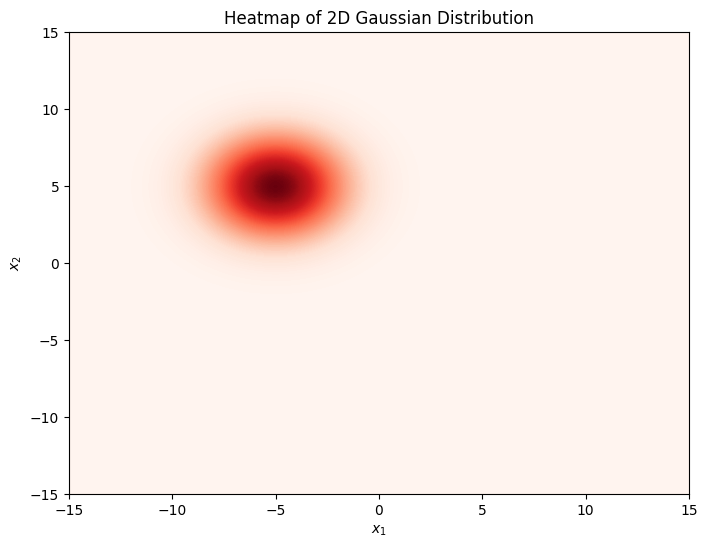

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf(x, y, mean, cov):
    pos = np.dstack((x, y))
    diff = pos - mean
    inv_cov = np.linalg.inv(cov)
    
    exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=-1)
    pdf = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov))) * np.exp(exponent)
    return pdf

mean = np.array([-5, 5])
cov = 5 * np.eye(2)
x, y = np.mgrid[-15:15:100j, -15:15:100j]

pdf = gaussian_pdf(x, y, mean, cov)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, pdf, levels = 150, cmap="Reds")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Heatmap of 2D Gaussian Distribution")
plt.show()


**Then implement the score function theoretically with the provided formula and pdf of the distribution**


**A multivariate Gaussian distribution with mean μ and covariance matrix Σ is given by:**
$$
p(x) = \frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2} (x-\mu)^T \Sigma^{-1} (x-\mu)\right)
$$
μ is the mean of the distribution (here, [−5,5]).

Σ is the covariance matrix (here, 5I).


**Computing the Score Function:**
$$
S_{\theta}(x) = \nabla_{x} \log p(x)
$$

$$
\log p(x) = -\log(10\pi) - \frac{1}{10} \left( (x_1 + 5)^2 + (x_2 - 5)^2 \right)
$$

$$
\nabla_x \log p(x) = \begin{bmatrix}
\frac{\partial \log p(x)}{\partial x_1} \\
\frac{\partial \log p(x)}{\partial x_2}
\end{bmatrix}
$$


$$
\frac{\partial \log p(x)}{\partial x_1} = -\frac{1}{10} \cdot 2(x_1 + 5) = -\frac{x_1 + 5}{5}
$$
$$
\frac{\partial \log p(x)}{\partial x_2} = -\frac{1}{10} \cdot 2(x_2 - 5) = -\frac{x_2 - 5}{5}
$$

$$
\nabla_x \log p(x) = \begin{bmatrix}
-\dfrac{x_1 + 5}{5} \\[10pt]
-\dfrac{x_2 - 5}{5}
\end{bmatrix}
$$

$$
\nabla_{x} \log p(x) = -\Sigma^{-1} (x - \mu)
$$

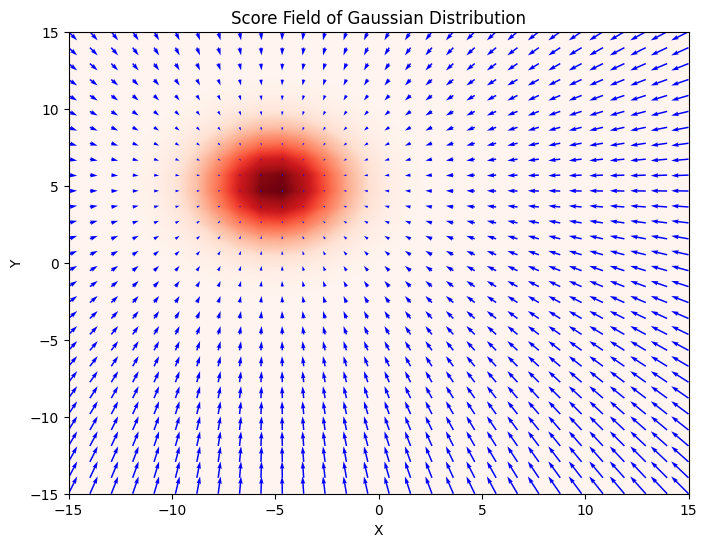

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def score_function(x, y, mean, cov):    
    inv_cov = np.linalg.inv(cov)
        
    score_x = -inv_cov[0, 0] * (x - mean[0]) - inv_cov[0, 1] * (y - mean[1])
    score_y = -inv_cov[1, 0] * (x - mean[0]) - inv_cov[1, 1] * (y - mean[1])

    return score_x, score_y

x, y = np.mgrid[-15:15:30j, -15:15:30j]
mean = np.array([-5, 5])

score_x, score_y = score_function(x, y, mean, cov)

plt.figure(figsize=(8, 6))
plt.contourf(x, y, pdf, levels = 150, cmap="Reds")
plt.quiver(x, y, score_x, score_y, color="blue")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Score Field of Gaussian Distribution")
plt.show()


**take sample using langevin dynamics algorithm :**


 Initialize a point randomly and Repeat until convergence
$$ X_{t+1} \gets X_t + \epsilon S_{\theta}(X_t) + \sqrt{2\epsilon} Z $$


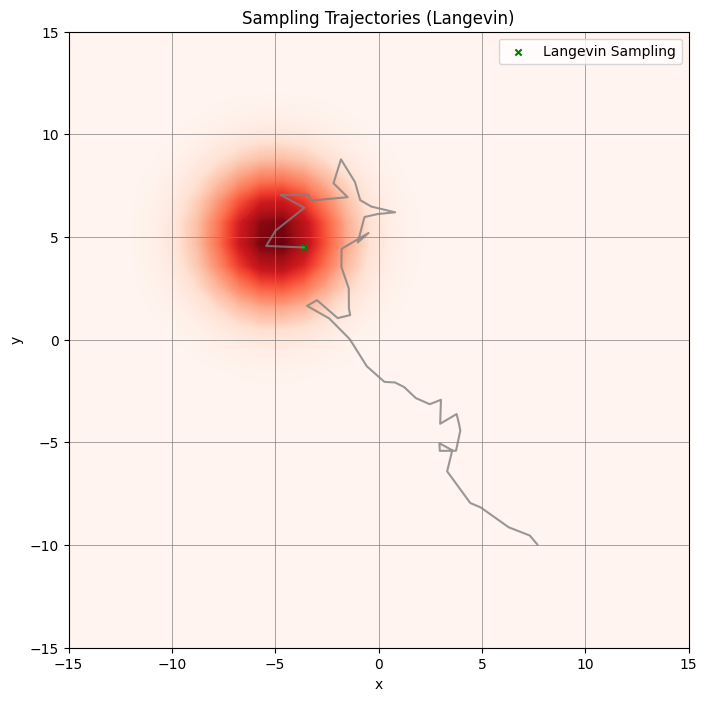

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def langevin_dynamics(x, y, mean, cov, epsilon, num_steps):
    trajectory = []
    for _ in range(num_steps):
        Zt_x = np.random.normal(0, 1)
        Zt_y = np.random.normal(0, 1)

        score_x, score_y = score_function(x, y, mean, cov)

        x = x + epsilon * score_x + np.sqrt(2 * epsilon) * Zt_x
        y = y + epsilon * score_y + np.sqrt(2 * epsilon) * Zt_y

        trajectory.append((x, y))

    return np.array(trajectory)
   

mean = np.array([-5, 5])
cov = 5 * np.eye(2)
x,y = np.random.uniform(-10, 10, (2,))
epsilon = 0.2
num_steps = 50  
trajectory = langevin_dynamics(x, y, mean, cov, epsilon, num_steps)

x_range, y_range = np.mgrid[-15:15:30j, -15:15:30j]

plt.figure(figsize=(8, 8))
plt.contourf(x_range, y_range, pdf, levels = 150, cmap="Reds")
plt.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.8, color='grey')
plt.scatter(trajectory[-1, 0], trajectory[-1, 1], color='green', marker='x', s = 20 , label="Langevin Sampling")
plt.grid(True, which='both', color='grey', linestyle='-', linewidth=0.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Sampling Trajectories (Langevin)")
plt.legend()
plt.show()


It is observed that the process starts from a random point and iterates continuously until it converges to the probability distribution.

**Comparing Samples :**


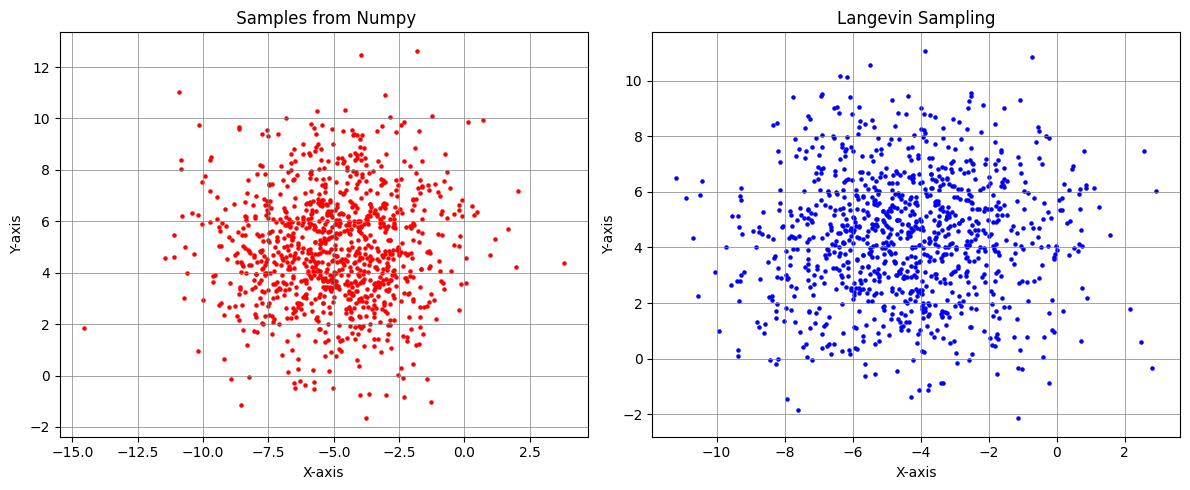

Langevin Sampling Mean :
Mean:
 [-4.41949853  4.37565381]
Cov: 
 [[5.56500912 0.20848566]
 [0.20848566 5.103714  ]]

Samples From Numpy :
Mean: 
 [-4.98628131  4.90678148]
Cov: 
 [[5.32865725 0.13766154]
 [0.13766154 4.85889745]]

Langevin Sampling Time: 0.2711 seconds
Direct Sampling Time: 0.0003 seconds


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def langevin_sampling(mean, cov, epsilon=0.2, num_steps=50, num_samples=1000):
    samples = []
    for _ in range(num_samples):
        x, y = np.random.uniform(-10, 10, (2,))
        for _ in range(num_steps):
            Zt_x = np.random.normal(0, 1)
            Zt_y = np.random.normal(0, 1)
            score_x, score_y = score_function(x, y, mean, cov)
            x = x + epsilon * score_x + np.sqrt(2 * epsilon) * Zt_x
            y = y + epsilon * score_y + np.sqrt(2 * epsilon) * Zt_y
        samples.append((x, y))
    return np.array(samples)

mean = np.array([-5, 5])
cov = 5 * np.eye(2)

start_time = time.time()
langevin_samples = langevin_sampling(mean, cov)
langevin_time = time.time() - start_time

start_time = time.time()
direct_samples = np.random.multivariate_normal(mean, cov, 1000)
direct_time = time.time() - start_time

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(direct_samples[:, 0], direct_samples[:, 1], s = 5, alpha = 1, color="red")
plt.grid(True, which='both', color='grey', linestyle='-', linewidth=0.5)
plt.title(" Samples from Numpy")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")


plt.subplot(1, 2, 2)
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], s = 5, alpha = 1, color="blue")
plt.grid(True, which='both', color='grey', linestyle='-', linewidth=0.5)
plt.title("Langevin Sampling")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.tight_layout()
plt.show()

print("Langevin Sampling Mean :")
print("Mean:\n", np.mean(langevin_samples, axis=0))
print("Cov: \n", np.cov(langevin_samples, rowvar=False))

print("\nSamples From Numpy :")
print("Mean: \n", np.mean(direct_samples, axis=0))
print("Cov: \n", np.cov(direct_samples, rowvar=False))


print(f"\nLangevin Sampling Time: {langevin_time:.4f} seconds")
print(f"Direct Sampling Time: {direct_time:.4f} seconds")


t is observed that the sample generated by NumPy has a more accurate mean and variance and is relatively faster than the Langevin Dynamics algorithm.


## Questions(5% Bonus)

If we compute its score function, it is obtained as follows:

$$
\nabla_x \log ps(x) = \frac{\alpha \nabla_x N_1 + (1-\alpha) \nabla_x N_2}{\alpha N_1 + (1-\alpha) N_2}
$$

**Numerical Consideration:**  
The score function calculation for Gaussian mixture models can be numerically unstable due to the common denominator term:

$$
\alpha N_1 + (1-\alpha) N_2
$$

particularly when the two Gaussian components have little overlap.

**Yes**, Langevin Dynamics can be used for sampling from Gaussian mixture models, but with two critical conditions:

1. The **score function** ($\nabla_x \log p(x)$) must be correctly computed (accounting for the mixture weight $\alpha$ and Gaussian components)
   
2. Parameters like the **learning rate** ($\epsilon$) and noise must be optimally tuned to avoid trapping in a single mode (e.g., $\mu_1$ or $\mu_2$)

In practice, this method works efficiently for simple mixtures, but may require auxiliary techniques for more complex distributions.